In [1]:
import numpy as np
import pandas as pd
import joblib
import json
import xgboost as xgb
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, average_precision_score, precision_recall_curve,
    classification_report, confusion_matrix
)

RANDOM_STATE = 42

In [2]:
X_train = pd.read_csv("X_train.csv", index_col=0)
X_val   = pd.read_csv("X_val.csv", index_col=0)
X_test  = pd.read_csv("X_test.csv", index_col=0)
y_train = pd.read_csv("y_train.csv", index_col=0).squeeze()
y_val   = pd.read_csv("y_val.csv", index_col=0).squeeze()
y_test  = pd.read_csv("y_test.csv", index_col=0).squeeze()

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)
print("Features:", list(X_train.columns))
assert "Class" not in X_train.columns
assert not any(c in X_train.columns for c in ["Record_ID", "Auction_ID", "Bidder_ID"])

Train: (4423, 9) Val: (949, 9) Test: (949, 9)
Features: ['Bidder_Tendency', 'Bidding_Ratio', 'Successive_Outbidding', 'Last_Bidding', 'Auction_Bids', 'Starting_Price_Average', 'Early_Bidding', 'Winning_Ratio', 'Auction_Duration']


In [3]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [4]:
X_train_normal_scaled = X_train_scaled[y_train.values == 0]
print(f"Training on {X_train_normal_scaled.shape[0]} normal-only samples")

iso_forest = IsolationForest(
    n_estimators=300,
    max_samples="auto",
    contamination="auto",
    random_state=RANDOM_STATE,
    n_jobs=-1
)
iso_forest.fit(X_train_normal_scaled)

Training on 3950 normal-only samples


,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",300
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary <n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",'auto'
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary <warm_start>`... versionadded:: 0.21",False
Name,Type,Value
estimator_ estimator_: :class:`~sklearn.tree.ExtraTreeRegressor` instanceThe child estimator template used to create the collection offitted sub-estimators... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,ExtraTreeRegressor,ExtraTreeRegr...ndom_state=42)


In [5]:
val_scores = -iso_forest.score_samples(X_val_scaled)
test_scores = -iso_forest.score_samples(X_test_scaled)

precisions, recalls, thresholds = precision_recall_curve(y_val, val_scores)
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-9)
best_idx = np.argmax(f1_scores)
iso_threshold = thresholds[best_idx]

val_auc = roc_auc_score(y_val, val_scores)
val_ap = average_precision_score(y_val, val_scores)
print(f"Val ROC-AUC: {val_auc:.4f} | PR-AUC: {val_ap:.4f}")
print(f"Best threshold: {iso_threshold:.4f} | F1: {f1_scores[best_idx]:.4f}")

Val ROC-AUC: 0.9897 | PR-AUC: 0.8476
Best threshold: 0.6115 | F1: 0.8720


In [6]:
test_preds_iso = (test_scores >= iso_threshold).astype(int)
test_auc = roc_auc_score(y_test, test_scores)
test_ap = average_precision_score(y_test, test_scores)

print(f" Isolation Forest — Test Results ")
print(f"ROC-AUC: {test_auc:.4f} | PR-AUC: {test_ap:.4f}")
print(classification_report(y_test, test_preds_iso, digits=4))
print(confusion_matrix(y_test, test_preds_iso))

 Isolation Forest — Test Results 
ROC-AUC: 0.9919 | PR-AUC: 0.9085
              precision    recall  f1-score   support

           0     0.9928    0.9752    0.9839       848
           1     0.8190    0.9406    0.8756       101

    accuracy                         0.9715       949
   macro avg     0.9059    0.9579    0.9298       949
weighted avg     0.9743    0.9715    0.9724       949

[[827  21]
 [  6  95]]


In [7]:
xgb_model = xgb.XGBClassifier()
xgb_model.load_model("final_xgb_shill_model.json")

with open("final_model_metadata.json") as f:
    xgb_metadata = json.load(f)

xgb_threshold = xgb_metadata["threshold"]
xgb_feature_order = xgb_metadata["feature_order"]

print("Loaded XGBoost model. Threshold:", xgb_threshold)
print("Feature order:", xgb_feature_order)

# Confirm feature order matches what Isolation Forest is using
assert list(X_train.columns) == xgb_feature_order, "Feature order mismatch between notebooks!"

Loaded XGBoost model. Threshold: 0.8519254326820374
Feature order: ['Bidder_Tendency', 'Bidding_Ratio', 'Successive_Outbidding', 'Last_Bidding', 'Auction_Bids', 'Starting_Price_Average', 'Early_Bidding', 'Winning_Ratio', 'Auction_Duration']


In [8]:
xgb_test_probs = xgb_model.predict_proba(X_test[xgb_feature_order])[:, 1]
xgb_test_preds = (xgb_test_probs >= xgb_threshold).astype(int)

print(classification_report(y_test, xgb_test_preds, digits=4))

              precision    recall  f1-score   support

           0     0.9976    0.9988    0.9982       848
           1     0.9900    0.9802    0.9851       101

    accuracy                         0.9968       949
   macro avg     0.9938    0.9895    0.9917       949
weighted avg     0.9968    0.9968    0.9968       949



In [9]:
y_test_arr = y_test.values

xgb_missed = (y_test_arr == 1) & (xgb_test_preds == 0)
caught_by_iso = xgb_missed & (test_preds_iso == 1)
both_missed = xgb_missed & (test_preds_iso == 0)

print(f"Shill bidders XGBoost missed: {xgb_missed.sum()}")
print(f" Caught by Isolation Forest: {caught_by_iso.sum()}")
print(f"  Missed by BOTH: {both_missed.sum()}")
print(f"Agreement rate: {(xgb_test_preds == test_preds_iso).mean():.3f}")

Shill bidders XGBoost missed: 2
 Caught by Isolation Forest: 2
  Missed by BOTH: 0
Agreement rate: 0.970


In [10]:
joblib.dump(iso_forest, "isolation_forest_model.pkl")
joblib.dump(scaler, "isolation_forest_scaler.pkl")

iso_metadata = {
    "threshold": float(iso_threshold),
    "feature_order": list(X_train.columns),
    "score_min": float(test_scores.min()),
    "score_max": float(test_scores.max()),
    "test_roc_auc": float(test_auc),
    "test_pr_auc": float(test_ap)
}

with open("isolation_forest_metadata.json", "w") as f:
    json.dump(iso_metadata, f, indent=2)

print("Metadata regenerated successfully.")
print(iso_metadata)


print("Saved: isolation_forest_model.pkl, isolation_forest_scaler.pkl, isolation_forest_metadata.json")

Metadata regenerated successfully.
{'threshold': 0.6114803972804356, 'feature_order': ['Bidder_Tendency', 'Bidding_Ratio', 'Successive_Outbidding', 'Last_Bidding', 'Auction_Bids', 'Starting_Price_Average', 'Early_Bidding', 'Winning_Ratio', 'Auction_Duration'], 'score_min': 0.4212098471538565, 'score_max': 0.7231134404118165, 'test_roc_auc': 0.9919320941528115, 'test_pr_auc': 0.9085411732205647}
Saved: isolation_forest_model.pkl, isolation_forest_scaler.pkl, isolation_forest_metadata.json


In [11]:
def combined_decision(new_data, xgb_model, xgb_threshold,
                       iso_model, iso_scaler, iso_threshold, feature_order):
    X_new = new_data[feature_order]

    xgb_prob = xgb_model.predict_proba(X_new)[:, 1]
    xgb_flag = xgb_prob >= xgb_threshold

    X_new_scaled = iso_scaler.transform(X_new)
    iso_score = -iso_model.score_samples(X_new_scaled)
    iso_flag = iso_score >= iso_threshold

    conditions = [xgb_flag & iso_flag, xgb_flag & ~iso_flag, ~xgb_flag & iso_flag]
    choices = ["auto_flag_high_confidence", "auto_flag_known_pattern", "manual_review"]
    decision = np.select(conditions, choices, default="approve")

    return pd.DataFrame({
        "xgb_probability": xgb_prob, "iso_anomaly_score": iso_score,
        "xgb_flag": xgb_flag, "iso_flag": iso_flag, "decision": decision
    }, index=new_data.index)

results = combined_decision(X_test, xgb_model, xgb_threshold,
                             iso_forest, scaler, iso_threshold, xgb_feature_order)
results["actual"] = y_test.values
print(results["decision"].value_counts())
print(pd.crosstab(results["decision"], results["actual"]))

decision
approve                      827
auto_flag_high_confidence     94
manual_review                 22
auto_flag_known_pattern        6
Name: count, dtype: int64
actual                       0   1
decision                          
approve                    827   0
auto_flag_high_confidence    1  93
auto_flag_known_pattern      0   6
manual_review               20   2


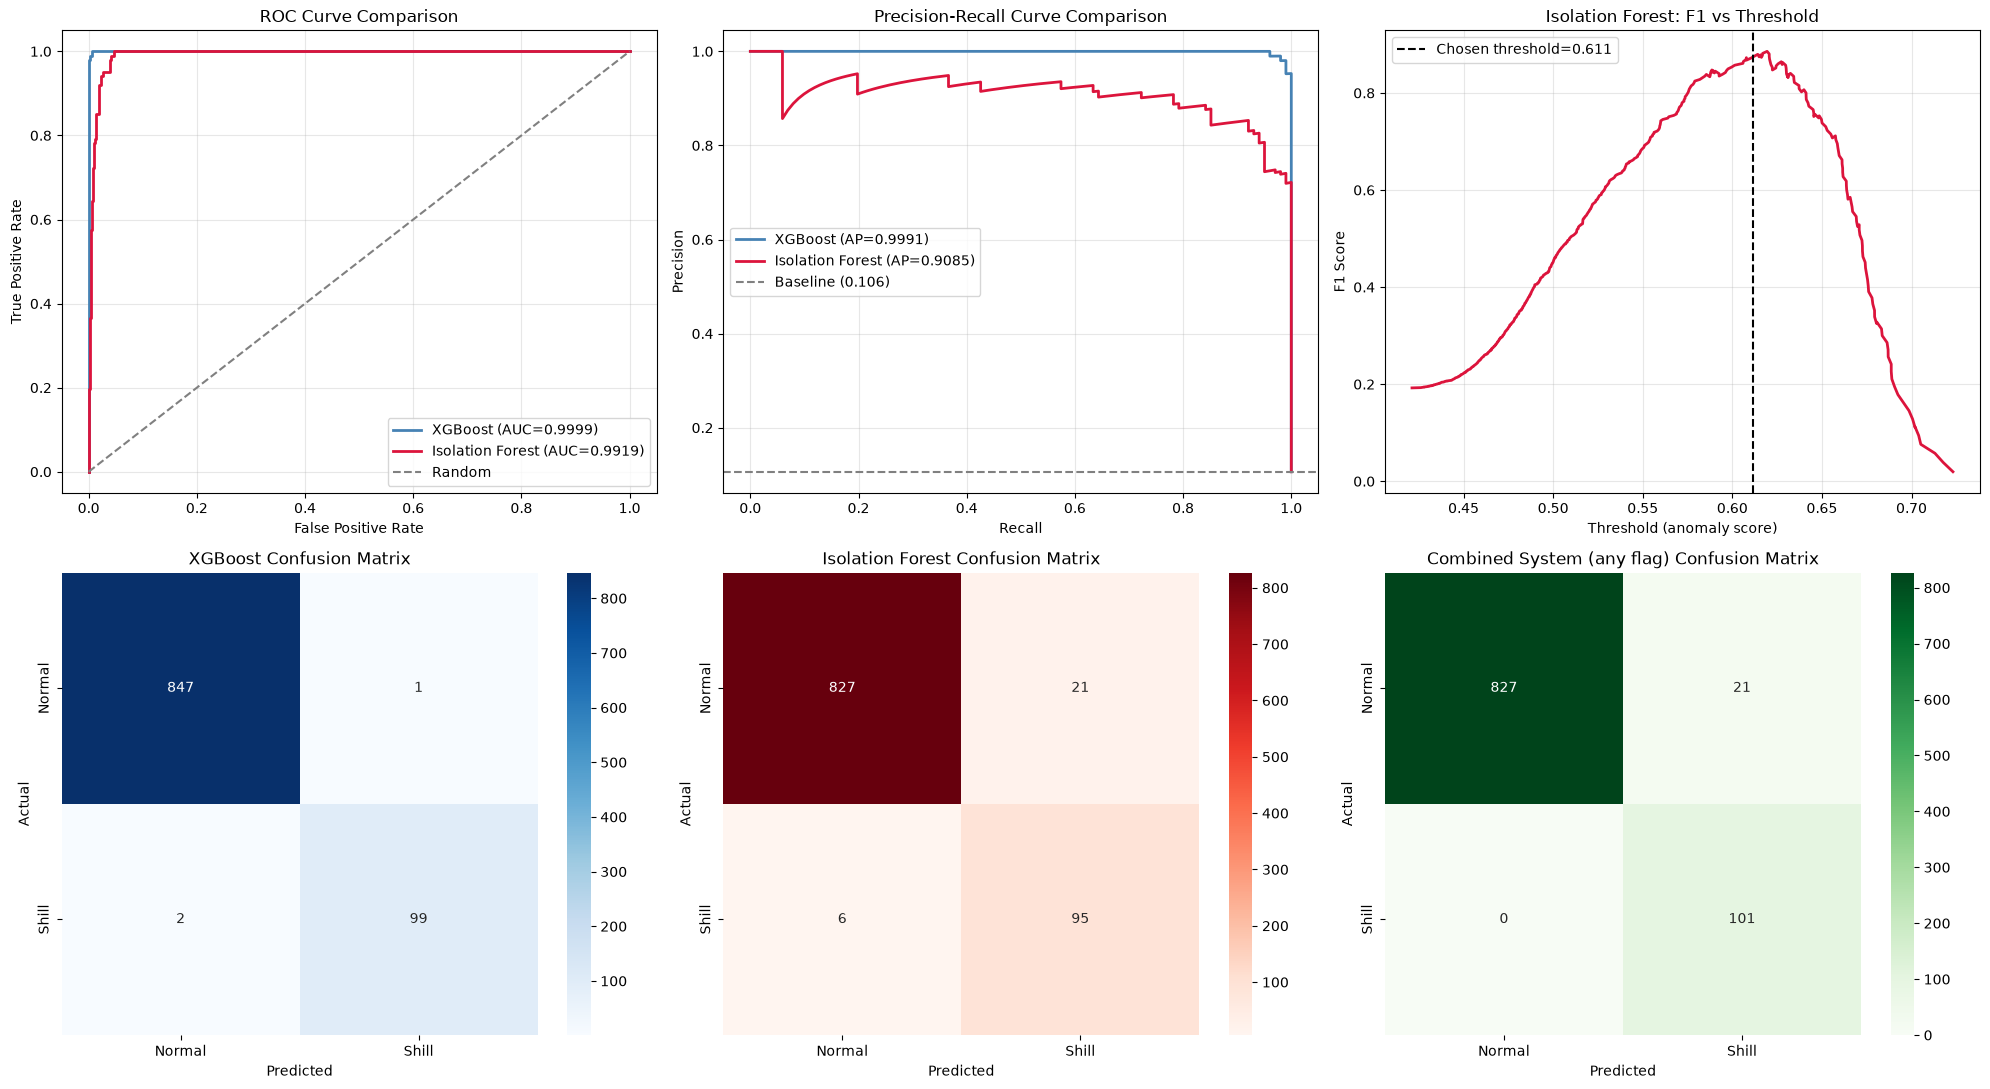

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    roc_curve, precision_recall_curve, auc,
    average_precision_score, confusion_matrix
)

y_test_arr = y_test.values


# Isolation Forest
fpr_iso, tpr_iso, _ = roc_curve(y_test_arr, test_scores)
roc_auc_iso = auc(fpr_iso, tpr_iso)
prec_iso, rec_iso, pr_thresh_iso = precision_recall_curve(y_test_arr, test_scores)
ap_iso = average_precision_score(y_test_arr, test_scores)

# XGBoost
fpr_xgb, tpr_xgb, _ = roc_curve(y_test_arr, xgb_test_probs)
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)
prec_xgb, rec_xgb, pr_thresh_xgb = precision_recall_curve(y_test_arr, xgb_test_probs)
ap_xgb = average_precision_score(y_test_arr, xgb_test_probs)

fig, axes = plt.subplots(2, 3, figsize=(20, 11))


axes[0, 0].plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC={roc_auc_xgb:.4f})", color="steelblue", linewidth=2)
axes[0, 0].plot(fpr_iso, tpr_iso, label=f"Isolation Forest (AUC={roc_auc_iso:.4f})", color="crimson", linewidth=2)
axes[0, 0].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random")
axes[0, 0].set_xlabel("False Positive Rate")
axes[0, 0].set_ylabel("True Positive Rate")
axes[0, 0].set_title("ROC Curve Comparison")
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)


axes[0, 1].plot(rec_xgb, prec_xgb, label=f"XGBoost (AP={ap_xgb:.4f})", color="steelblue", linewidth=2)
axes[0, 1].plot(rec_iso, prec_iso, label=f"Isolation Forest (AP={ap_iso:.4f})", color="crimson", linewidth=2)
baseline = y_test_arr.sum() / len(y_test_arr)
axes[0, 1].axhline(baseline, linestyle="--", color="gray", label=f"Baseline ({baseline:.3f})")
axes[0, 1].set_xlabel("Recall")
axes[0, 1].set_ylabel("Precision")
axes[0, 1].set_title("Precision-Recall Curve Comparison")
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)


f1_iso = 2 * (prec_iso[:-1] * rec_iso[:-1]) / (prec_iso[:-1] + rec_iso[:-1] + 1e-9)
axes[0, 2].plot(pr_thresh_iso, f1_iso, color="crimson", linewidth=2)
axes[0, 2].axvline(iso_threshold, linestyle="--", color="black",
                    label=f"Chosen threshold={iso_threshold:.3f}")
axes[0, 2].set_xlabel("Threshold (anomaly score)")
axes[0, 2].set_ylabel("F1 Score")
axes[0, 2].set_title("Isolation Forest: F1 vs Threshold")
axes[0, 2].legend()
axes[0, 2].grid(alpha=0.3)


cm_xgb = confusion_matrix(y_test_arr, xgb_test_preds)
sns.heatmap(cm_xgb, annot=True, fmt="d", cmap="Blues", ax=axes[1, 0],
            xticklabels=["Normal", "Shill"], yticklabels=["Normal", "Shill"])
axes[1, 0].set_title("XGBoost Confusion Matrix")
axes[1, 0].set_xlabel("Predicted")
axes[1, 0].set_ylabel("Actual")


cm_iso = confusion_matrix(y_test_arr, test_preds_iso)
sns.heatmap(cm_iso, annot=True, fmt="d", cmap="Reds", ax=axes[1, 1],
            xticklabels=["Normal", "Shill"], yticklabels=["Normal", "Shill"])
axes[1, 1].set_title("Isolation Forest Confusion Matrix")
axes[1, 1].set_xlabel("Predicted")
axes[1, 1].set_ylabel("Actual")



combined_pred = results["decision"].isin(
    ["auto_flag_high_confidence", "auto_flag_known_pattern", "manual_review"]
).astype(int)
cm_combined = confusion_matrix(y_test_arr, combined_pred)
sns.heatmap(cm_combined, annot=True, fmt="d", cmap="Greens", ax=axes[1, 2],
            xticklabels=["Normal", "Shill"], yticklabels=["Normal", "Shill"])
axes[1, 2].set_title("Combined System (any flag) Confusion Matrix")
axes[1, 2].set_xlabel("Predicted")
axes[1, 2].set_ylabel("Actual")

plt.tight_layout()
plt.savefig("model_comparison_diagnostics.png", dpi=150, bbox_inches="tight")
plt.show()

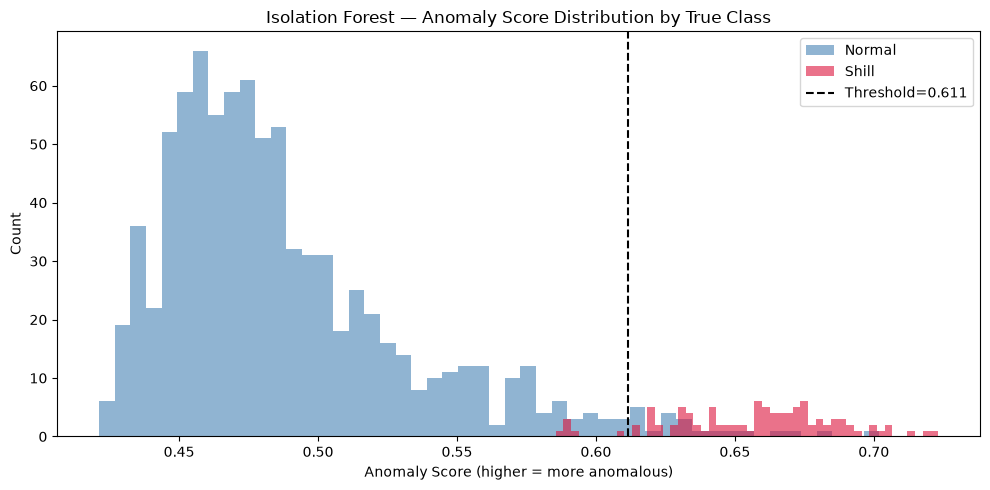

In [13]:
plt.figure(figsize=(10, 5))
plt.hist(test_scores[y_test_arr == 0], bins=50, alpha=0.6, label="Normal", color="steelblue")
plt.hist(test_scores[y_test_arr == 1], bins=50, alpha=0.6, label="Shill", color="crimson")
plt.axvline(iso_threshold, color="black", linestyle="--", label=f"Threshold={iso_threshold:.3f}")
plt.xlabel("Anomaly Score (higher = more anomalous)")
plt.ylabel("Count")
plt.title("Isolation Forest — Anomaly Score Distribution by True Class")
plt.legend()
plt.tight_layout()
plt.savefig("iso_forest_score_distribution.png", dpi=150)
plt.show()

In [14]:
from sklearn.metrics import classification_report

summary = pd.DataFrame({
    "XGBoost": {
        "ROC-AUC": roc_auc_xgb,
        "PR-AUC": ap_xgb,
        "Precision (shill)": classification_report(y_test_arr, xgb_test_preds, output_dict=True)["1"]["precision"],
        "Recall (shill)": classification_report(y_test_arr, xgb_test_preds, output_dict=True)["1"]["recall"],
        "F1 (shill)": classification_report(y_test_arr, xgb_test_preds, output_dict=True)["1"]["f1-score"],
    },
    "Isolation Forest": {
        "ROC-AUC": roc_auc_iso,
        "PR-AUC": ap_iso,
        "Precision (shill)": classification_report(y_test_arr, test_preds_iso, output_dict=True)["1"]["precision"],
        "Recall (shill)": classification_report(y_test_arr, test_preds_iso, output_dict=True)["1"]["recall"],
        "F1 (shill)": classification_report(y_test_arr, test_preds_iso, output_dict=True)["1"]["f1-score"],
    },
    "Combined (any flag)": {
        "ROC-AUC": np.nan,  #
        "PR-AUC": np.nan,
        "Precision (shill)": classification_report(y_test_arr, combined_pred, output_dict=True)["1"]["precision"],
        "Recall (shill)": classification_report(y_test_arr, combined_pred, output_dict=True)["1"]["recall"],
        "F1 (shill)": classification_report(y_test_arr, combined_pred, output_dict=True)["1"]["f1-score"],
    }
}).T

print(summary.round(4))
summary.to_csv("model_comparison_summary.csv")

                     ROC-AUC  PR-AUC  Precision (shill)  Recall (shill)  \
XGBoost               0.9999  0.9991             0.9900          0.9802   
Isolation Forest      0.9919  0.9085             0.8190          0.9406   
Combined (any flag)      NaN     NaN             0.8279          1.0000   

                     F1 (shill)  
XGBoost                  0.9851  
Isolation Forest         0.8756  
Combined (any flag)      0.9058  


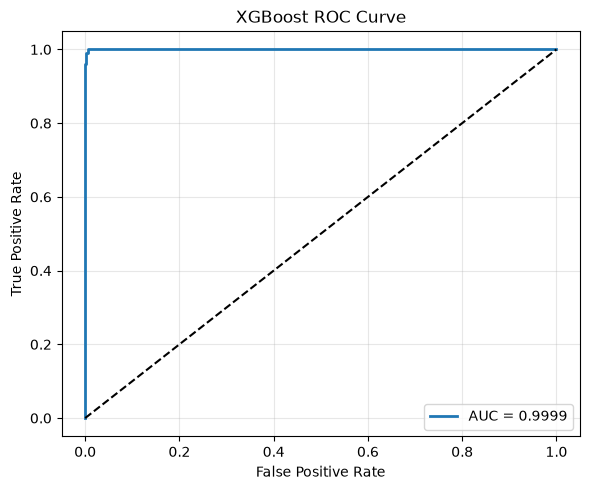

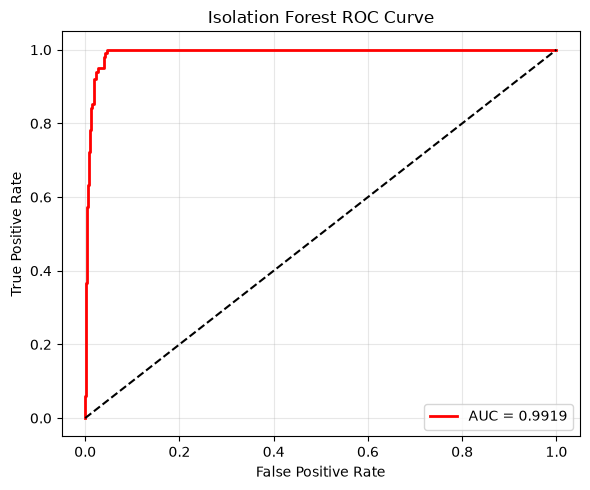

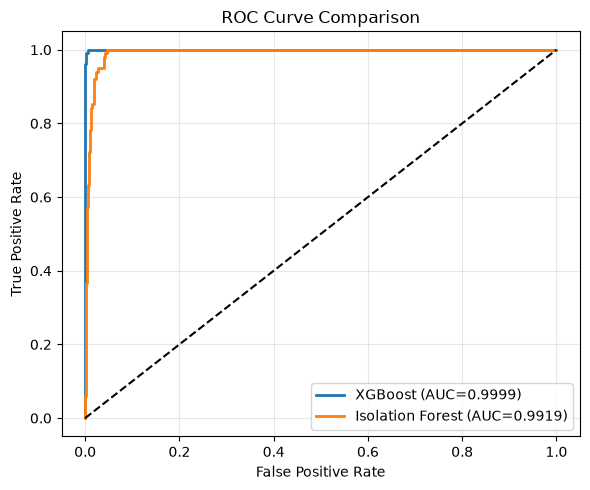

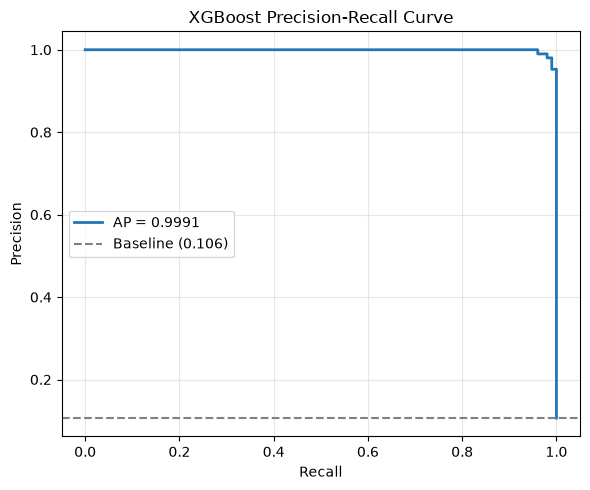

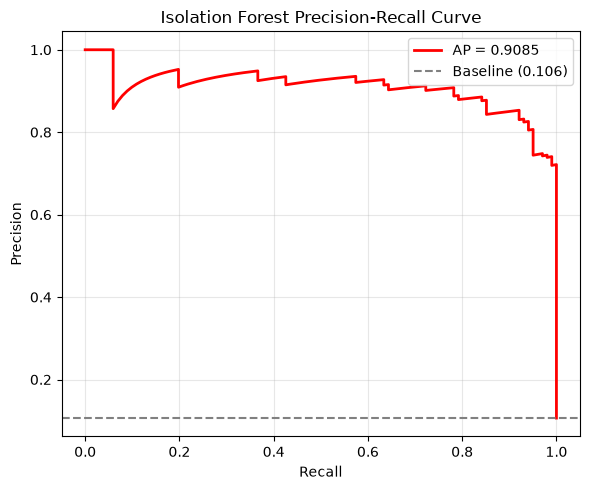

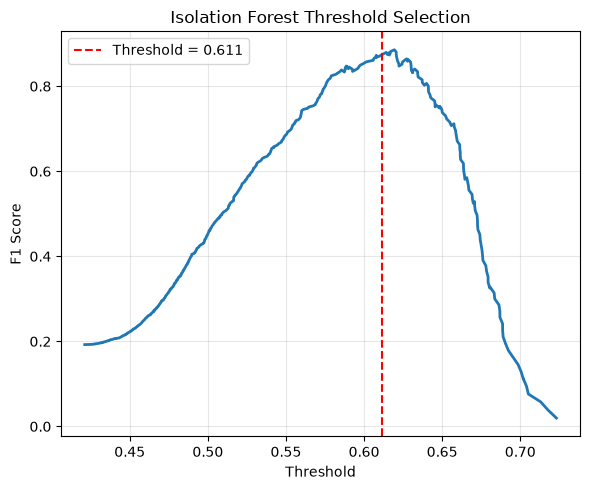

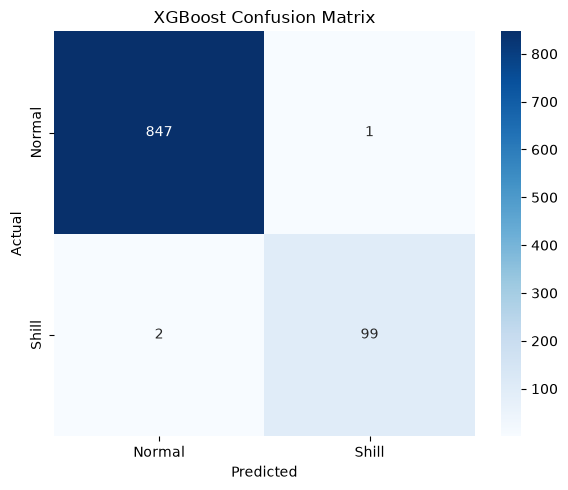

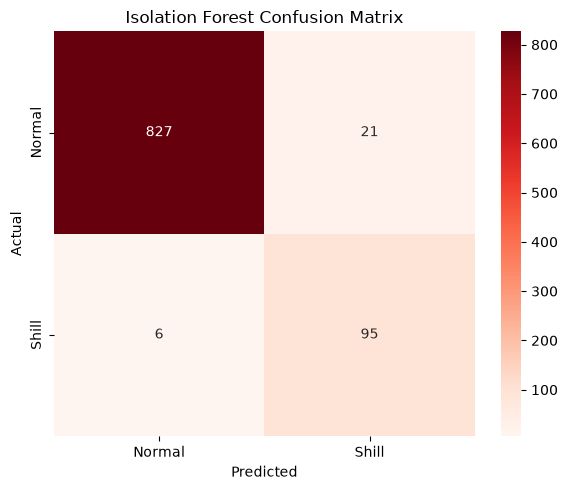

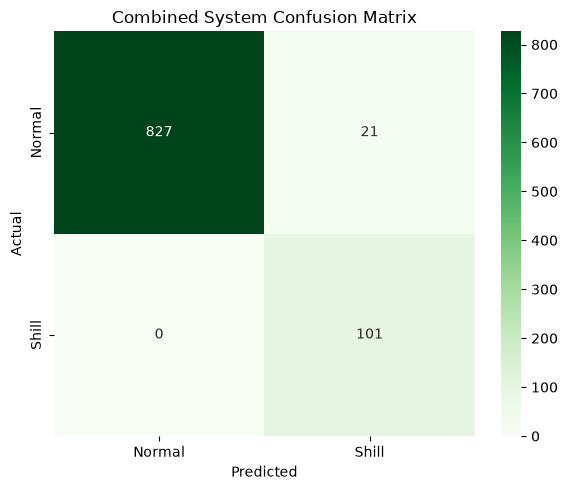

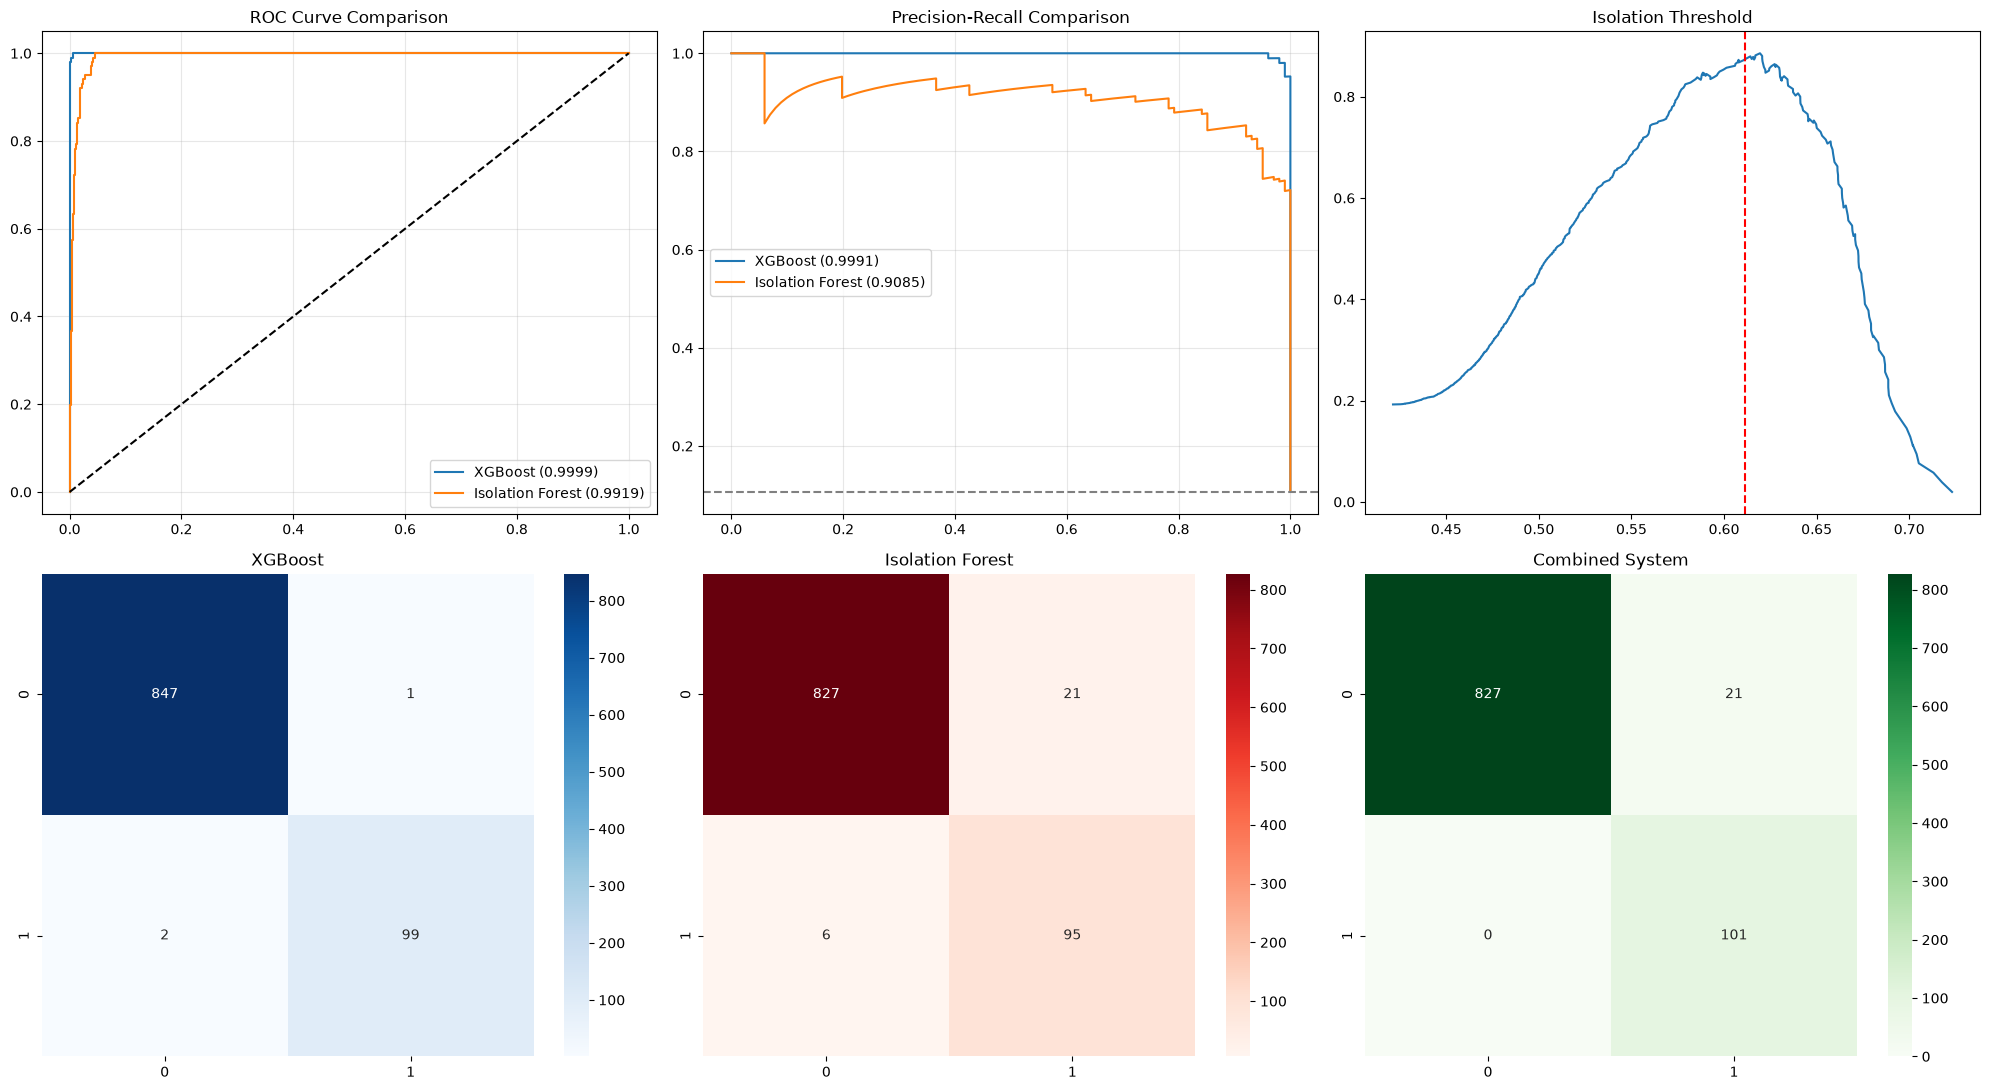

All figures saved successfully.


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    roc_curve,
    precision_recall_curve,
    auc,
    average_precision_score,
    confusion_matrix,
)

y_test_arr = y_test.values



# Isolation Forest
fpr_iso, tpr_iso, _ = roc_curve(y_test_arr, test_scores)
roc_auc_iso = auc(fpr_iso, tpr_iso)

prec_iso, rec_iso, pr_thresh_iso = precision_recall_curve(
    y_test_arr,
    test_scores
)
ap_iso = average_precision_score(y_test_arr, test_scores)

# XGBoost
fpr_xgb, tpr_xgb, _ = roc_curve(y_test_arr, xgb_test_probs)
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)

prec_xgb, rec_xgb, pr_thresh_xgb = precision_recall_curve(
    y_test_arr,
    xgb_test_probs
)
ap_xgb = average_precision_score(y_test_arr, xgb_test_probs)

baseline = y_test_arr.sum() / len(y_test_arr)



plt.figure(figsize=(6,5))
plt.plot(fpr_xgb, tpr_xgb, linewidth=2,
         label=f"AUC = {roc_auc_xgb:.4f}")
plt.plot([0,1],[0,1],"k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("XGBoost ROC Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("xgboost_roc_curve.png", dpi=300)
plt.show()



plt.figure(figsize=(6,5))
plt.plot(fpr_iso, tpr_iso,
         color="red",
         linewidth=2,
         label=f"AUC = {roc_auc_iso:.4f}")

plt.plot([0,1],[0,1],"k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Isolation Forest ROC Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("isolation_forest_roc_curve.png", dpi=300)
plt.show()



plt.figure(figsize=(6,5))

plt.plot(
    fpr_xgb,
    tpr_xgb,
    linewidth=2,
    label=f"XGBoost (AUC={roc_auc_xgb:.4f})"
)

plt.plot(
    fpr_iso,
    tpr_iso,
    linewidth=2,
    label=f"Isolation Forest (AUC={roc_auc_iso:.4f})"
)

plt.plot([0,1],[0,1],"k--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("roc_comparison.png", dpi=300)
plt.show()



plt.figure(figsize=(6,5))

plt.plot(
    rec_xgb,
    prec_xgb,
    linewidth=2,
    label=f"AP = {ap_xgb:.4f}"
)

plt.axhline(
    baseline,
    linestyle="--",
    color="gray",
    label=f"Baseline ({baseline:.3f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("XGBoost Precision-Recall Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("xgboost_pr_curve.png", dpi=300)
plt.show()



plt.figure(figsize=(6,5))

plt.plot(
    rec_iso,
    prec_iso,
    color="red",
    linewidth=2,
    label=f"AP = {ap_iso:.4f}"
)

plt.axhline(
    baseline,
    linestyle="--",
    color="gray",
    label=f"Baseline ({baseline:.3f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Isolation Forest Precision-Recall Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("isolation_forest_pr_curve.png", dpi=300)
plt.show()


f1_iso = (
    2 * (prec_iso[:-1] * rec_iso[:-1])
    / (prec_iso[:-1] + rec_iso[:-1] + 1e-9)
)

plt.figure(figsize=(6,5))

plt.plot(
    pr_thresh_iso,
    f1_iso,
    linewidth=2
)

plt.axvline(
    iso_threshold,
    linestyle="--",
    color="red",
    label=f"Threshold = {iso_threshold:.3f}"
)

plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.title("Isolation Forest Threshold Selection")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("isolation_threshold_selection.png", dpi=300)
plt.show()



cm_xgb = confusion_matrix(
    y_test_arr,
    xgb_test_preds
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_xgb,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal","Shill"],
    yticklabels=["Normal","Shill"]
)

plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("xgboost_confusion_matrix.png", dpi=300)
plt.show()



cm_iso = confusion_matrix(
    y_test_arr,
    test_preds_iso
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_iso,
    annot=True,
    fmt="d",
    cmap="Reds",
    xticklabels=["Normal","Shill"],
    yticklabels=["Normal","Shill"]
)

plt.title("Isolation Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("isolation_forest_confusion_matrix.png", dpi=300)
plt.show()



combined_pred = results["decision"].isin([
    "auto_flag_high_confidence",
    "auto_flag_known_pattern",
    "manual_review"
]).astype(int)

cm_combined = confusion_matrix(
    y_test_arr,
    combined_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_combined,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Normal","Shill"],
    yticklabels=["Normal","Shill"]
)

plt.title("Combined System Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("combined_confusion_matrix.png", dpi=300)
plt.show()

# ==============================
# COMBINED 2x3 FIGURE
# ==============================

fig, axes = plt.subplots(2,3,figsize=(20,11))

# ROC
axes[0,0].plot(fpr_xgb,tpr_xgb,label=f"XGBoost ({roc_auc_xgb:.4f})")
axes[0,0].plot(fpr_iso,tpr_iso,label=f"Isolation Forest ({roc_auc_iso:.4f})")
axes[0,0].plot([0,1],[0,1],"k--")
axes[0,0].set_title("ROC Curve Comparison")
axes[0,0].legend()
axes[0,0].grid(alpha=0.3)

# PR
axes[0,1].plot(rec_xgb,prec_xgb,label=f"XGBoost ({ap_xgb:.4f})")
axes[0,1].plot(rec_iso,prec_iso,label=f"Isolation Forest ({ap_iso:.4f})")
axes[0,1].axhline(baseline,linestyle="--",color="gray")
axes[0,1].set_title("Precision-Recall Comparison")
axes[0,1].legend()
axes[0,1].grid(alpha=0.3)

# Threshold
axes[0,2].plot(pr_thresh_iso,f1_iso)
axes[0,2].axvline(iso_threshold,color="red",linestyle="--")
axes[0,2].set_title("Isolation Threshold")

sns.heatmap(cm_xgb,annot=True,fmt="d",cmap="Blues",ax=axes[1,0])
axes[1,0].set_title("XGBoost")

sns.heatmap(cm_iso,annot=True,fmt="d",cmap="Reds",ax=axes[1,1])
axes[1,1].set_title("Isolation Forest")

sns.heatmap(cm_combined,annot=True,fmt="d",cmap="Greens",ax=axes[1,2])
axes[1,2].set_title("Combined System")

plt.tight_layout()
plt.savefig("model_comparison_diagnostics.png", dpi=300)
plt.show()

print("All figures saved successfully.")